# **1. 논리회귀**
논리 회귀(Logistic Regression)는 주어진 입력 데이터를 기반으로 두 가지 이상의 범주로 분류하는 지도 학습 알고리즘입니다. 주로 이진 분류 문제에 사용되며, 입력 변수의 선형 결합을 통해 특정 사건이 발생할 확률을 예측합니다. 이 알고리즘은 시그모이드(Sigmoid) 함수 또는 로지스틱 함수라는 비선형 함수를 사용하여 예측값을 0과 1 사이의 확률로 변환합니다. 모델의 결과는 일반적으로 특정 임계값(예: 0.5)을 기준으로 두 범주 중 하나로 분류됩니다. 예를 들어, 이메일이 스팸인지 아닌지를 판별하거나 환자의 병 진단 여부를 예측하는 데 사용될 수 있습니다. 논리 회귀는 계산이 비교적 간단하고 해석이 용이하여 머신러닝에서 널리 사용되는 알고리즘입니다.

예측이 아닌 분류

# **2. 단항 논리 회귀**
단항 논리 회귀 (Univariate Logistic Regression)는 하나의 독립 변수(입력 변수)를 사용하여 이진 분류 문제를 해결하는 논리 회귀(Logistic Regression)의 한 형태입니다. 예를 들어, 학생의 하루 공부 시간(독립 변수)에 따라 시험 합격 여부(종속 변수: 합격/불합격)를 예측하는 경우가 여기에 해당합니다. 단항 논리 회귀는 입력 변수의 값을 시그모이드(Sigmoid) 함수에 전달하여 해당 사건(예: 합격)이 발생할 확률(0과 1 사이의 값)을 계산합니다. 이후 이 확률 값이 특정 임계값(일반적으로 0.5)을 초과하면 한 클래스로, 그렇지 않으면 다른 클래스로 분류합니다. 단항 논리 회귀는 간단하면서도 직관적이어서 이진 분류 문제를 설명하고 해석하는 데 자주 사용됩니다.

In [62]:
import torch
import torch.nn as nn

In [63]:
# 선형회귀라면 식은
# z = W1*x1 + W2*x2 + W3*x3 + b
# z = 0.1*1.0 + 0.2*2.0 + 0.3*3.0 + 0.5 -> 내적, 행렬곱과 계산이 같음

# 선형회귀에서는 추론이 다 된 값이 logit.
# 논리회귀에서는 추론에 쓰이는 값을 logit이라 함. 이 값을 이용해 분류함.

x = torch.tensor([1.0, 2.0, 3.0])
W = torch.tensor([0.1, 0.2, 0.3]) # weight, 기울기
b = torch.tensor(0.5)
z = torch.dot(W,x)+b

print(z)

tensor(1.9000)


In [64]:
sigmoid = nn.Sigmoid()
output = sigmoid(z)
print(output)

tensor(0.8699)


```
output = model(x) # 출력 값은 logit. logit = -∞ ~ +∞
# -3.0, 0.0, 2.0, 5.0
# 값 자체는 범위 제한이 없기 때문에 클래스가 x일 확률이라고 해석하기 어려움
# 그래서 Sigmoid를 적용!!!
```

### ※ 시그모이드 함수

시그모이드 함수(Sigmoid Function)는 입력 값을 받아서 이를 0과 1 사이의 값으로 변환하는 수학 함수입니다. 주로 확률을 예측해야 하는 문제에서 사용됩니다. 논리 회귀(Logistic Regression)와 인공신경망(Artificial Neural Network)에서 매우 중요한 역할을 합니다. (e: 자연 상수로, 약 2.718입니다.)

![시그모이드](./images/시그모이드.png)
![시그모이드 함수](./images/시그모이드%20함수.png)

In [65]:
test = torch.tensor([-3.0, 0.0, 2.0, 5.0])
prob = torch.sigmoid(test)
prob

tensor([0.0474, 0.5000, 0.8808, 0.9933])

> Sigmoid는 logit의 범위를 단순히 줄이는 함수라기보다, 이진 분류에서 모델의 출력을 0 ~ 1 사이로 변환하여 클래스 1에 대한 확률처럼 해석할 수 있게 만드는 함수

In [66]:
import torch.optim as optim
import matplotlib.pyplot as plt

In [67]:
torch.manual_seed(2026)

In [68]:
# 자격증 시험 공부한 시간
# 0시간, 1시간, 3시간, ...
x_train = torch.FloatTensor([[0], [1], [3], [5], [8], [11], [15], [20]])
# 합격 여부
# 불합격, 불합격, ...
y_train = torch.FloatTensor([[0], [0], [0], [0], [1], [1], [1], [1]])
print(x_train.shape)
print(y_train.shape)

torch.Size([8, 1])
torch.Size([8, 1])


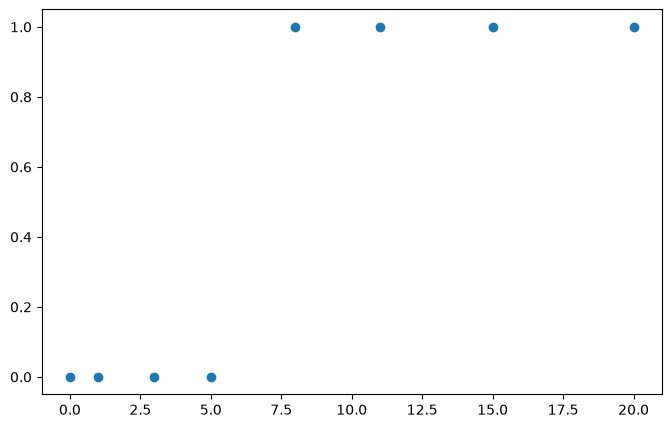

In [69]:
plt.figure(figsize=(8, 5))
plt.scatter(x_train, y_train)

In [70]:
# Sequential에 여러 모델을 쓸 수 있음
model = nn.Sequential(
    nn.Linear(1,1),
    nn.Sigmoid()
)

model

Sequential(
  (0): Linear(in_features=1, out_features=1, bias=True)
  (1): Sigmoid()
)

In [71]:
list(model.parameters())

[Parameter containing:
 tensor([[-0.6950]], requires_grad=True),
 Parameter containing:
 tensor([-0.4962], requires_grad=True)]

In [72]:
y_pred = model(x_train)
y_pred

tensor([[3.7844e-01],
        [2.3304e-01],
        [7.0353e-02],
        [1.8499e-02],
        [2.3372e-03],
        [2.9109e-04],
        [1.8061e-05],
        [5.5911e-07]], grad_fn=<SigmoidBackward0>)

회귀와 분류는 오차함수가 서로 다름

### BCE 손실 함수

Binary Cross Entropy (BCE)는 이진 분류 문제에서 모델이 예측한 확률 분포와 실제 정답 레이블 사이의 차이를 측정하는 손실 함수(Loss Function)입니다. BCE는 예측된 확률 값과 실제 값(0 또는 1) 사이의 차이를 로그 확률로 변환하여 손실을 계산합니다.

![BCE](./images/BCE.png)
![BCE 손실 함수](./images/BCE%20손실%20함수.png)

In [73]:
loss = nn.BCELoss()(y_pred, y_train)
loss

tensor(5.0440, grad_fn=<BinaryCrossEntropyBackward0>)

In [74]:
optimizer = optim.SGD(model.parameters(), lr=0.01)

In [75]:
epochs = 1000

for epoch in range(1, epochs + 1):
    y_pred = model(x_train)
    loss = nn.BCELoss()(y_pred, y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 100 == 0:
        print(f'Epoch: {epoch}/{epochs} Loss: {loss:.6f}')

Epoch: 100/1000 Loss: 0.396054
Epoch: 200/1000 Loss: 0.367661
Epoch: 300/1000 Loss: 0.343323
Epoch: 400/1000 Loss: 0.322311
Epoch: 500/1000 Loss: 0.304039
Epoch: 600/1000 Loss: 0.288036
Epoch: 700/1000 Loss: 0.273923
Epoch: 800/1000 Loss: 0.261396
Epoch: 900/1000 Loss: 0.250209
Epoch: 1000/1000 Loss: 0.240160


In [76]:
list(model.parameters())

[Parameter containing:
 tensor([[0.3517]], requires_grad=True),
 Parameter containing:
 tensor([-1.7588], requires_grad=True)]

In [77]:
x_test = torch.FloatTensor([[10]])
y_pred = model(x_test)
y_pred

tensor([[0.8530]], grad_fn=<SigmoidBackward0>)

In [78]:
# 임계치 설정하기
# 0.5보다 크거나 같으면 1
# 0.5보다 작으면 0
y_bool = (y_pred >= 0.5).float()
y_bool

tensor([[1.]])

# **3. 다항 논리 회귀**
다항 논리 회귀(Multinomial Logistic Regression)는 종속 변수가 세 개 이상의 범주로 나뉘는 다중 클래스 분류 문제를 해결하는 알고리즘입니다. 예를 들어, 과일의 색깔이 빨강, 노랑, 초록 중 하나로 분류되는 문제에서 사용할 수 있습니다. 이 알고리즘은 각 클래스에 대한 확률을 예측하기 위해 소프트맥스(Softmax) 함수를 사용합니다. 소프트맥스 함수는 각 클래스에 속할 확률을 0과 1 사이의 값으로 변환하며, 모든 클래스의 확률 합이 1이 되도록 정규화합니다. 모델은 입력 데이터가 특정 클래스에 속할 가능성을 계산한 뒤, 가장 높은 확률을 가진 클래스를 최종 예측 값으로 선택합니다. 다항 논리 회귀는 자연어 처리, 이미지 분류, 그리고 다양한 다중 클래스 분류 문제에서 널리 사용됩니다.

In [79]:
x_train = [
    # 국어, 영어, 수학, 출석
    [55, 58, 60, 70],   # C
    [60, 62, 65, 75],   # C
    [63, 65, 67, 78],   # C

    [72, 74, 75, 85],   # B
    [75, 78, 80, 88],   # B
    [80, 82, 81, 90],   # B

    [88, 90, 91, 95],   # A
    [92, 94, 93, 97],   # A
    [95, 96, 98, 98],   # A
    [98, 99, 100, 100]  # A
]

y_train = [
    0, 0, 0,   # C등급
    1, 1, 1,   # B등급
    2, 2, 2, 2 # A등급
]

In [80]:
x_train = torch.FloatTensor(x_train)
y_train = torch.LongTensor(y_train)
print(x_train.shape)
print(y_train.shape)

torch.Size([10, 4])
torch.Size([10])


In [81]:
model = nn.Sequential(
    nn.Linear(4, 3)
)
model

Sequential(
  (0): Linear(in_features=4, out_features=3, bias=True)
)

입력 (1,4) ( 가중치 ) =  결과(1,3)
따라서 가중치의 형태는 (4,3)이 되어야 함

![다항 논리회귀](./images/다항논리회귀.png)

In [82]:
list(model.parameters())

[Parameter containing:
 tensor([[ 0.2310, -0.4357, -0.4813, -0.0055],
         [ 0.2581, -0.4991,  0.1982, -0.4535],
         [ 0.3129, -0.3046,  0.2241,  0.1406]], requires_grad=True),
 Parameter containing:
 tensor([-0.1009, -0.1628,  0.4120], requires_grad=True)]

In [83]:
y_pred = model(x_train)
y_pred

tensor([[-41.9305, -34.7673,  23.2490],
        [-44.9524, -36.7496,  25.4191],
        [-46.5456, -38.4367,  26.3142],
        [-52.2771, -42.1943,  29.1668],
        [-55.7500, -43.7859,  30.4298],
        [-56.8302, -45.2004,  31.2815],
        [-63.3086, -47.4136,  34.2927],
        [-65.1011, -48.8881,  35.0556],
        [-67.6916, -48.5744,  36.6465],
        [-69.2794, -49.8079,  37.4010]], grad_fn=<AddmmBackward0>)

### CrossEntropyLoss

CrossEntropyLoss는 다중 클래스 분류(Multiclass Classification) 문제에서 모델의 예측과 실제 정답 레이블 간의 차이를 측정하는 손실 함수(Loss Function)입니다. 이 함수는 모델이 예측한 확률 분포와 실제 레이블(정답) 간의 불확실성을 수치화합니다. CrossEntropyLoss는 주로 Softmax 함수와 함께 사용됩니다. Softmax는 각 클래스에 대한 확률 분포를 제공하며, CrossEntropyLoss는 이 확률 분포와 실제 레이블 간의 차이를 계산합니다. 예측이 실제 레이블과 가까울수록 손실 값이 작아지며, 예측이 틀릴수록 손실 값은 커집니다.

내부에 softmax가 내장되어 logit을 crossentropyloss에 넣으면 확률값을 구해 오차까지 계산해준다.

![크로스엔트로피](./images/crossentropyloss.png)
![크로스엔트로피예](./images/크로스엔트로피예.png)

```
PyTorch의 nn.CrossEntropyLoss에는 Softmax와 로그 연산이 내부적으로 포함되어 있음

1. 모델이 내놓은 값은 확률이 아니라 logit
2. Softmax를 적용하면 확률처럼 바뀜(nn.CrossEntropy 포함)
3. 그래서 CrossEntropyLoss 결과에 직접 Softmax를 하지 않음
```

### Softmax

Softmax 함수는 다중 클래스 분류(Multiclass Classification) 문제에서 사용되는 활성화 함수(Activation Function)입니다. 이 함수는 주어진 입력 벡터의 각 요소를 확률 분포(probability distribution)로 변환합니다. 즉, 각 클래스에 대한 예측값을 0과 1 사이의 값으로 변환하며, 모든 클래스의 확률 합이 항상 1이 되도록 정규화합니다.

In [84]:
loss = nn.CrossEntropyLoss()(y_pred, y_train)
loss

tensor(43.0469, grad_fn=<NllLossBackward0>)

In [85]:
optimizer = optim.SGD(model.parameters(), lr=0.01)

In [86]:
epochs = 10000

for epoch in range(epochs + 1):
    y_pred = model(x_train)
    loss = nn.CrossEntropyLoss()(y_pred, y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 100 == 0:
        print(f'Epoch: {epoch}/{epochs} Loss: {loss: .6f}')

Epoch: 0/10000 Loss:  43.046947
Epoch: 100/10000 Loss:  60.727062
Epoch: 200/10000 Loss:  54.470863
Epoch: 300/10000 Loss:  10.857373
Epoch: 400/10000 Loss:  35.575985
Epoch: 500/10000 Loss:  45.614662
Epoch: 600/10000 Loss:  3.472153
Epoch: 700/10000 Loss:  24.635328
Epoch: 800/10000 Loss:  17.028461
Epoch: 900/10000 Loss:  0.000038
Epoch: 1000/10000 Loss:  0.000019
Epoch: 1100/10000 Loss:  0.000015
Epoch: 1200/10000 Loss:  0.000014
Epoch: 1300/10000 Loss:  0.000014
Epoch: 1400/10000 Loss:  0.000014
Epoch: 1500/10000 Loss:  0.000013
Epoch: 1600/10000 Loss:  0.000013
Epoch: 1700/10000 Loss:  0.000013
Epoch: 1800/10000 Loss:  0.000013
Epoch: 1900/10000 Loss:  0.000013
Epoch: 2000/10000 Loss:  0.000013
Epoch: 2100/10000 Loss:  0.000013
Epoch: 2200/10000 Loss:  0.000013
Epoch: 2300/10000 Loss:  0.000013
Epoch: 2400/10000 Loss:  0.000013
Epoch: 2500/10000 Loss:  0.000013
Epoch: 2600/10000 Loss:  0.000013
Epoch: 2700/10000 Loss:  0.000013
Epoch: 2800/10000 Loss:  0.000013
Epoch: 2900/10000 

In [89]:
x_test = torch.FloatTensor([[90, 91, 93, 92]])
y_pred = model(x_test)
y_pred

tensor([[-101.3807,  -20.5611,   46.7745]], grad_fn=<AddmmBackward0>)

In [ ]:
# logit을 확률로 변환
y_prob = nn.Softmax(1)(y_pred) # 1은 축방향(열) 지정
y_prob

tensor([[0.0000e+00, 5.7081e-30, 1.0000e+00]], grad_fn=<SoftmaxBackward0>)

In [ ]:
# tensor([[0.0000e+00, 5.7081e-30, 1.0000e+00]]) 이라 [0][0]으로 꺼냄
print(f'0일 확률: {y_prob[0][0]:.2f}')
print(f'1일 확률: {y_prob[0][1]:.2f}')
print(f'2일 확률: {y_prob[0][2]:.2f}')

0일 확률: 0.00
1일 확률: 0.00
2일 확률: 1.00


In [92]:
torch.argmax(y_prob, axis=1)

tensor([2])